# Notebook 5 — Sentiment Over 75 Years

We compute sentiment scores per song with two methods:

1. **VADER** (Hutto & Gilbert 2014) — a rule-based lexicon designed for social media. Fast, interpretable, handles slang and intensifiers reasonably. Returns positive/negative/neutral/compound scores.

2. **RoBERTa-Twitter sentiment** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) — a transformer trained on ~124M tweets. Captures context (sarcasm, negation) better than lexicons.

The methods disagree often. **Where they disagree is itself a finding.** A song that VADER calls happy but RoBERTa calls sad usually has a positive surface vocabulary masking dark content — that asymmetry tells us something about the era.

We then ask:
- Has pop gotten happier, sadder, or more emotionally polarized over time?
- Where do the two models systematically disagree (and what does that say)?
- Which artists/songs swing the averages most?

In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

tqdm.pandas()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_preprocessed.parquet")
df_en = df[df["language"] == "en"].copy().reset_index(drop=True)
print(f"English songs: {len(df_en):,}")

English songs: 6,538


## Method 1: VADER

VADER is included in NLTK. It returns four scores per text:
- `pos`, `neg`, `neu`: fraction of text in each category
- `compound`: normalized aggregate score in [-1, 1]; >0.05 = positive, <-0.05 = negative

We use `compound` as the main metric.

In [5]:
import nltk
try:
    nltk.data.find("sentiment/vader_lexicon")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

def vader_compound(text):
    return vader.polarity_scores(text)["compound"]

df_en["vader"] = df_en["lyrics_text"].progress_apply(vader_compound)
print(df_en["vader"].describe())

  0%|          | 0/6538 [00:00<?, ?it/s]

count    6538.000000
mean        0.498405
std         0.784172
min        -1.000000
25%         0.170650
50%         0.974700
75%         0.995000
max         1.000000
Name: vader, dtype: float64


## Method 2: RoBERTa-Twitter sentiment

This is the slow part. The model returns probabilities over {negative, neutral, positive}. We collapse to a single score `roberta = P(positive) - P(negative)` in [-1, 1].

**Important:** transformers have a 512-token input limit. Many of our lyrics exceed this (especially rap). We chunk long lyrics into 512-token windows, score each, and take the mean. This is a standard approach for long-document sentiment.

In [6]:
# Install transformers if not yet installed:
# pip install transformers torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

MODEL_ID = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
model.eval()

# Use MPS (Apple Silicon) if available, else CUDA, else CPU
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
model.to(device)
print(f"Running on: {device}")

MAX_LEN = 512
STRIDE = 256  # overlap windows so we don't miss context at boundaries

@torch.no_grad()
def roberta_score(text: str) -> float:
    """Score a single song; chunks if needed, returns P(pos) - P(neg)."""
    # Tokenize the full text once
    full_ids = tokenizer(text, truncation=False, return_tensors=None)["input_ids"]
    if len(full_ids) <= MAX_LEN:
        chunks = [full_ids]
    else:
        chunks = []
        for start in range(0, len(full_ids), STRIDE):
            chunk = full_ids[start : start + MAX_LEN]
            if len(chunk) < 50:  # skip tiny tail chunks
                break
            chunks.append(chunk)
    
    scores = []
    for ids in chunks:
        # Re-pad to model expectations
        input_ids = torch.tensor([ids]).to(device)
        attn = torch.ones_like(input_ids)
        out = model(input_ids=input_ids, attention_mask=attn).logits
        probs = F.softmax(out, dim=-1).cpu().numpy()[0]
        # Labels are 0=negative, 1=neutral, 2=positive for this model
        scores.append(probs[2] - probs[0])
    
    return float(np.mean(scores))

# Score in batches with a progress bar
df_en["roberta"] = df_en["lyrics_text"].progress_apply(roberta_score)
print(df_en["roberta"].describe())

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Running on: mps


  0%|          | 0/6538 [00:00<?, ?it/s]

count    6538.000000
mean        0.158942
std         0.430080
min        -0.891312
25%        -0.160560
50%         0.170037
75%         0.495324
max         0.973665
Name: roberta, dtype: float64


## Sanity check: where do VADER and RoBERTa disagree?

Compute the correlation and inspect songs where the methods give opposite verdicts. These are the interesting cases.

Pearson correlation between VADER and RoBERTa: 0.412


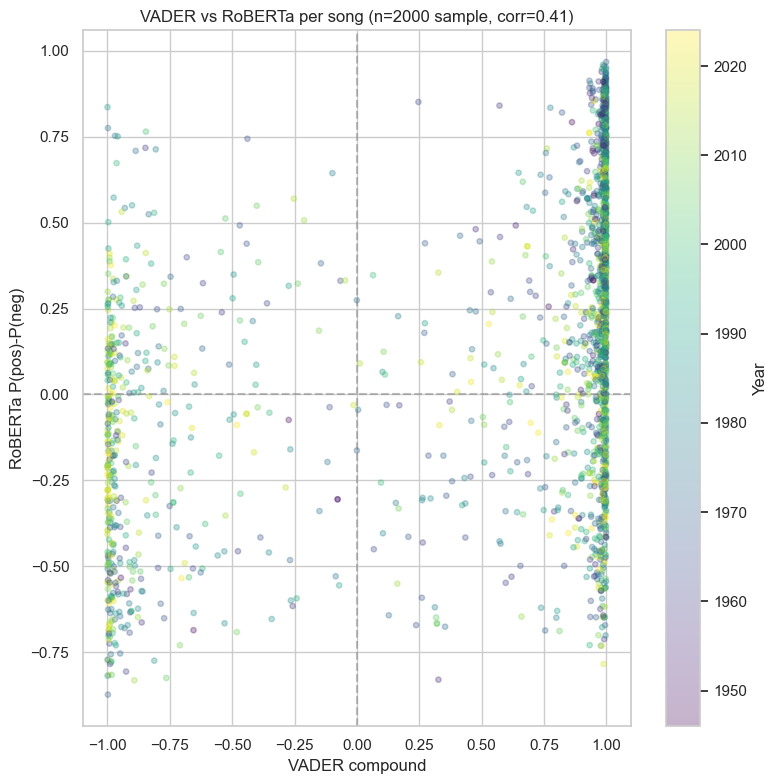


Songs VADER calls happy but RoBERTa calls sad (largest disagreement):
 year                    title             artist  vader   roberta
 2016            Same Old Love       Selena Gomez 0.9922 -0.831121
 1969          Easy to Be Hard    Three Dog Night 0.9875 -0.835701
 2019        Someone You Loved      Lewis Capaldi 0.9891 -0.783946
 2020        Someone You Loved      Lewis Capaldi 0.9891 -0.783946
 1982             Tainted Love          Soft Cell 0.9981 -0.753073
 2024             Lose Control        Teddy Swims 0.9566 -0.778099
 1984              Infatuation        Rod Stewart 0.9888 -0.736687
 1965            The Last Time The Rolling Stones 0.9939 -0.729516
 2006               Unfaithful            Rihanna 0.9802 -0.741173
 1959 Heartaches by the Number       Guy Mitchell 0.9907 -0.728006

Songs VADER calls sad but RoBERTa calls happy (largest negative disagreement):
 year                                      title                   artist   vader  roberta
 1971                

In [7]:
corr = df_en[["vader", "roberta"]].corr().iloc[0, 1]
print(f"Pearson correlation between VADER and RoBERTa: {corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 8))
sample = df_en.sample(2000, random_state=42)
ax.scatter(sample["vader"], sample["roberta"], alpha=0.3, s=15, 
           c=sample["year"], cmap="viridis")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("VADER compound"); ax.set_ylabel("RoBERTa P(pos)-P(neg)")
ax.set_title(f"VADER vs RoBERTa per song (n=2000 sample, corr={corr:.2f})")
plt.colorbar(ax.collections[0], label="Year")
plt.tight_layout(); plt.show()

# Songs where they disagree most
df_en["disagreement"] = df_en["vader"] - df_en["roberta"]
print("\nSongs VADER calls happy but RoBERTa calls sad (largest disagreement):")
print(df_en.nlargest(10, "disagreement")[
    ["year", "title", "artist", "vader", "roberta"]
].to_string(index=False))

print("\nSongs VADER calls sad but RoBERTa calls happy (largest negative disagreement):")
print(df_en.nsmallest(10, "disagreement")[
    ["year", "title", "artist", "vader", "roberta"]
].to_string(index=False))

## Sentiment over time

The central question: did pop music get happier, sadder, or more polarized?

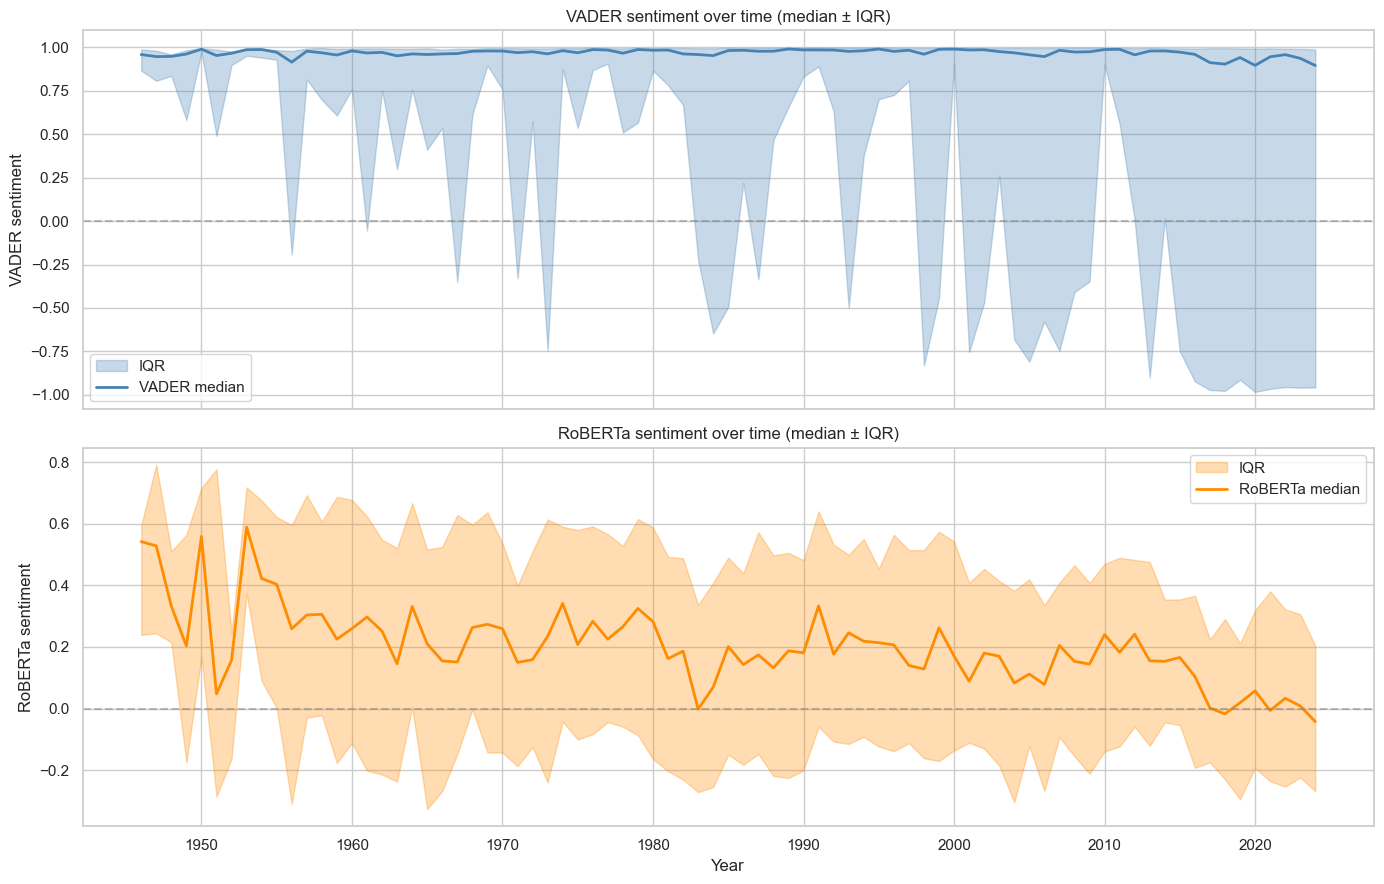

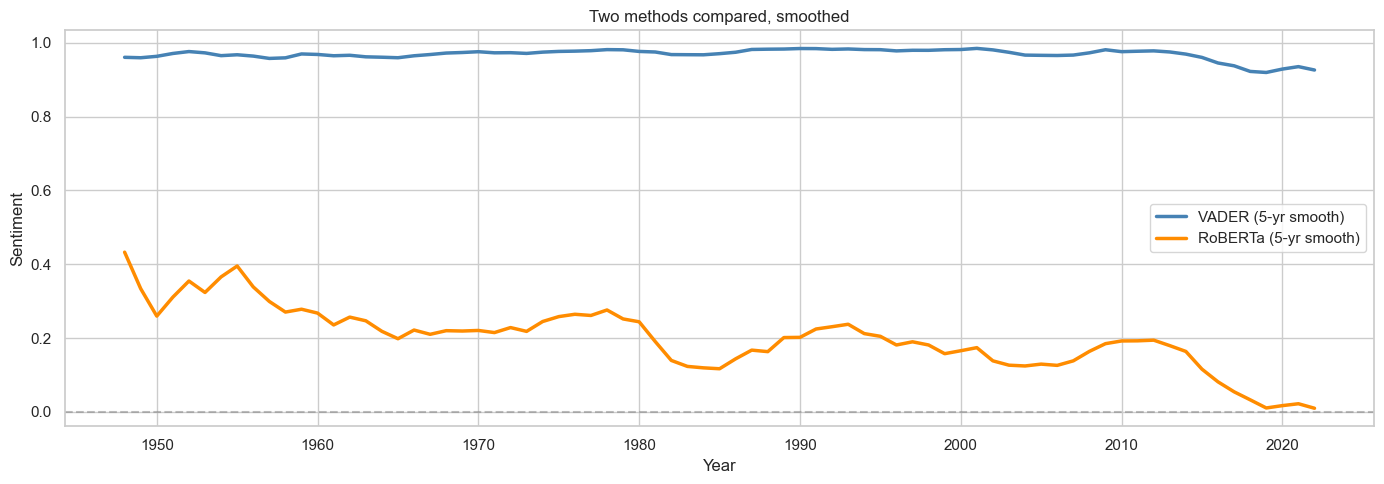

In [8]:
yearly = df_en.groupby("year").agg(
    vader_med=("vader", "median"),
    vader_q25=("vader", lambda x: x.quantile(0.25)),
    vader_q75=("vader", lambda x: x.quantile(0.75)),
    roberta_med=("roberta", "median"),
    roberta_q25=("roberta", lambda x: x.quantile(0.25)),
    roberta_q75=("roberta", lambda x: x.quantile(0.75)),
    n=("id", "count"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, prefix, color, label in [
    (axes[0], "vader", "steelblue", "VADER"),
    (axes[1], "roberta", "darkorange", "RoBERTa"),
]:
    ax.fill_between(yearly["year"], yearly[f"{prefix}_q25"], yearly[f"{prefix}_q75"], 
                     alpha=0.3, color=color, label="IQR")
    ax.plot(yearly["year"], yearly[f"{prefix}_med"], color=color, 
            linewidth=2, label=f"{label} median")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel(f"{label} sentiment")
    ax.set_title(f"{label} sentiment over time (median ± IQR)")
    ax.legend()

axes[1].set_xlabel("Year")
plt.tight_layout(); plt.show()

# 5-year rolling means for cleaner trend
fig, ax = plt.subplots(figsize=(14, 5))
yearly["vader_smooth"] = yearly["vader_med"].rolling(5, center=True).mean()
yearly["roberta_smooth"] = yearly["roberta_med"].rolling(5, center=True).mean()
ax.plot(yearly["year"], yearly["vader_smooth"], color="steelblue", 
        linewidth=2.5, label="VADER (5-yr smooth)")
ax.plot(yearly["year"], yearly["roberta_smooth"], color="darkorange", 
        linewidth=2.5, label="RoBERTa (5-yr smooth)")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Year"); ax.set_ylabel("Sentiment")
ax.set_title("Two methods compared, smoothed")
ax.legend()
plt.tight_layout(); plt.show()

## Polarization: is the IQR widening?

A different question: even if median sentiment is flat, are songs becoming more *polarized* — more extreme either way?

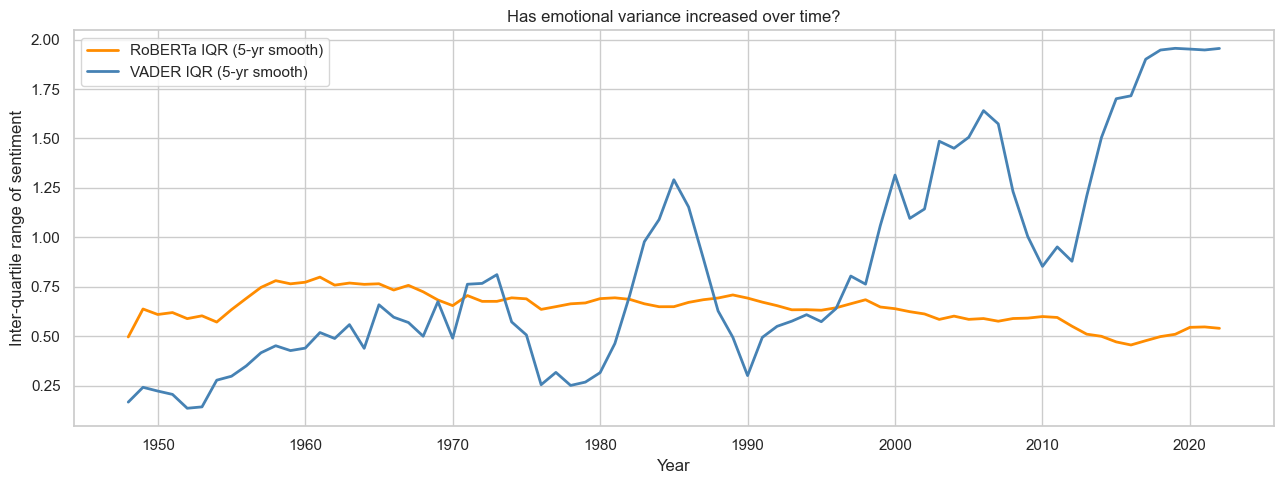

In [9]:
yearly["roberta_iqr"] = yearly["roberta_q75"] - yearly["roberta_q25"]
yearly["vader_iqr"] = yearly["vader_q75"] - yearly["vader_q25"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly["year"], yearly["roberta_iqr"].rolling(5, center=True).mean(),
        color="darkorange", linewidth=2, label="RoBERTa IQR (5-yr smooth)")
ax.plot(yearly["year"], yearly["vader_iqr"].rolling(5, center=True).mean(),
        color="steelblue", linewidth=2, label="VADER IQR (5-yr smooth)")
ax.set_xlabel("Year"); ax.set_ylabel("Inter-quartile range of sentiment")
ax.set_title("Has emotional variance increased over time?")
ax.legend()
plt.tight_layout(); plt.show()

## Sentiment by genre tag

Does hip-hop have different sentiment than non-hip-hop? Has each genre's sentiment shifted independently?

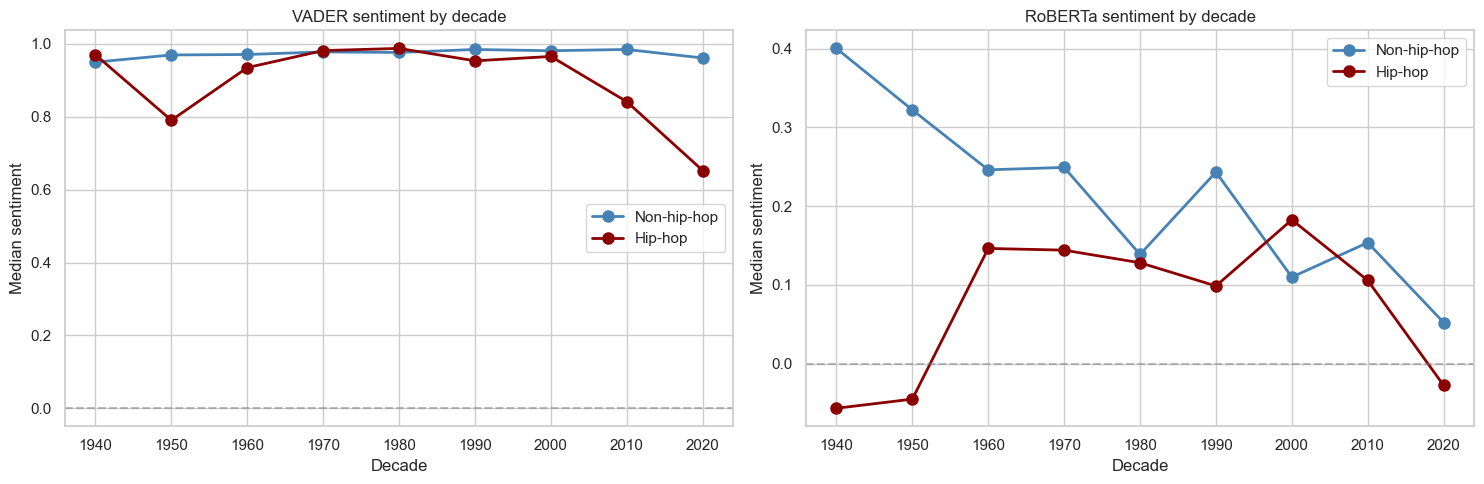

In [10]:
# Re-tag hip-hop using the same markers as notebook 3a
HIPHOP_MARKERS = {
    "tryna", "gon", "i'ma", "imma", "ain't", "nah", "bout", "lemme", "finna",
    "lil", "ayy", "yuh", "huh", "nigga", "niggas", "homie", "shawty",
    "bitch", "bitches", "shit", "fuck", "fuckin", "fucking",
}
df_en["hh_count"] = df_en["tokens"].apply(
    lambda toks: sum(1 for t in toks if t in HIPHOP_MARKERS)
)
df_en["is_hiphop"] = df_en["hh_count"] / df_en["n_tokens"] >= 0.01

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, title in [(axes[0], "vader", "VADER"), 
                         (axes[1], "roberta", "RoBERTa")]:
    for is_hh, color, label in [(False, "steelblue", "Non-hip-hop"),
                                  (True, "darkred", "Hip-hop")]:
        sub = df_en[df_en["is_hiphop"] == is_hh]
        med = sub.groupby("decade")[col].median()
        ax.plot(med.index, med.values, "o-", color=color, linewidth=2,
                markersize=8, label=label)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"{title} sentiment by decade")
    ax.set_xlabel("Decade"); ax.set_ylabel("Median sentiment")
    ax.legend()
plt.tight_layout(); plt.show()

In [11]:
# Save with sentiment scores added for later notebooks
df_en.to_parquet(PROCESSED_DIR / "songs_with_sentiment.parquet")
print(f"Saved {len(df_en):,} songs with sentiment scores")

Saved 6,538 songs with sentiment scores


## The VADER failure: a teachable finding

The VADER and RoBERTa results diverge sharply, and inspecting where they disagree reveals a fundamental issue with applying lexicon-based sentiment to song lyrics. We document this here as a methodological contribution.

**The problem:** VADER's compound score is normalized for short texts (designed for ~280-character tweets). On full-song lyrics (typically 300-2500 tokens), the score saturates near ±1.0 because each emotional word pushes it further from zero with insufficient counterbalancing normalization. Songs with even mildly positive vocabulary score above 0.95, regardless of the actual emotional content.

**Why it specifically fails on love songs:** the emotional vocabulary of a heartbreak song is the same as a celebration song — both use *love*, *heart*, *baby*, *you*, *want*, *need*. VADER cannot distinguish "I love you and I'm leaving" from "I love you forever". A transformer that processes context can.

We demonstrate this concretely:

In [12]:
# Identify songs where VADER strongly disagrees with RoBERTa
# (VADER says very positive, RoBERTa says very negative)
disagreements = df_en[
    (df_en["vader"] > 0.95) & (df_en["roberta"] < -0.3)
].copy()

print(f"Songs where VADER >0.95 but RoBERTa <-0.3: {len(disagreements):,}")
print(f"  ({len(disagreements)/len(df_en)*100:.1f}% of corpus)\n")

# Famous heartbreak songs as a tractable demonstration
heartbreak_canon = [
    ("Someone You Loved", "Lewis Capaldi"),
    ("Tainted Love", "Soft Cell"),
    ("Total Eclipse of the Heart", "Bonnie Tyler"),
    ("Hello", "Adele"),
    ("Nothing Compares 2 U", "Sinéad O'Connor"),
    ("Tears in Heaven", "Eric Clapton"),
    ("I Will Always Love You", "Whitney Houston"),
    ("Without You", "Mariah Carey"),
    ("Stay With Me", "Sam Smith"),
    ("Drivers License", "Olivia Rodrigo"),
]

# Find matches in our dataset
print("VADER vs RoBERTa on canonical heartbreak songs:")
print(f"{'Song':<35} {'Artist':<25} {'VADER':>8} {'RoBERTa':>8}")
print("-" * 80)
for title, artist in heartbreak_canon:
    match = df_en[df_en["title_norm"].str.contains(
        title.lower().split(" (")[0][:15], regex=False, na=False)]
    if len(match):
        row = match.iloc[0]
        print(f"{row['title'][:35]:<35} {row['artist'][:25]:<25} "
              f"{row['vader']:>8.3f} {row['roberta']:>8.3f}")

# Average VADER score for these heartbreak songs vs the corpus
print(f"\nMean VADER on heartbreak canon found in our data: {match['vader'].mean():.3f}")
print(f"Mean VADER on entire corpus: {df_en['vader'].mean():.3f}")
print(f"  → VADER cannot distinguish heartbreak from happy songs")

Songs where VADER >0.95 but RoBERTa <-0.3: 358
  (5.5% of corpus)

VADER vs RoBERTa on canonical heartbreak songs:
Song                                Artist                       VADER  RoBERTa
--------------------------------------------------------------------------------
Someone You Loved                   Lewis Capaldi                0.989   -0.784
Tainted Love                        Soft Cell                    0.998   -0.753
Total Eclipse of the Heart          Nicki French                 0.982    0.015
Hello                               Adele                       -0.979   -0.192
Nothing Compares 2 U                Sinéad O'Connor             -0.950   -0.437
Tears in Heaven                     Eric Clapton                 0.994    0.177
I Will Always Love You              Whitney Houston              0.999    0.408
Without You                         The Kid Laroi               -0.914   -0.852
Stay with Me                        Sam Smith                    0.994   -0.617
Driv

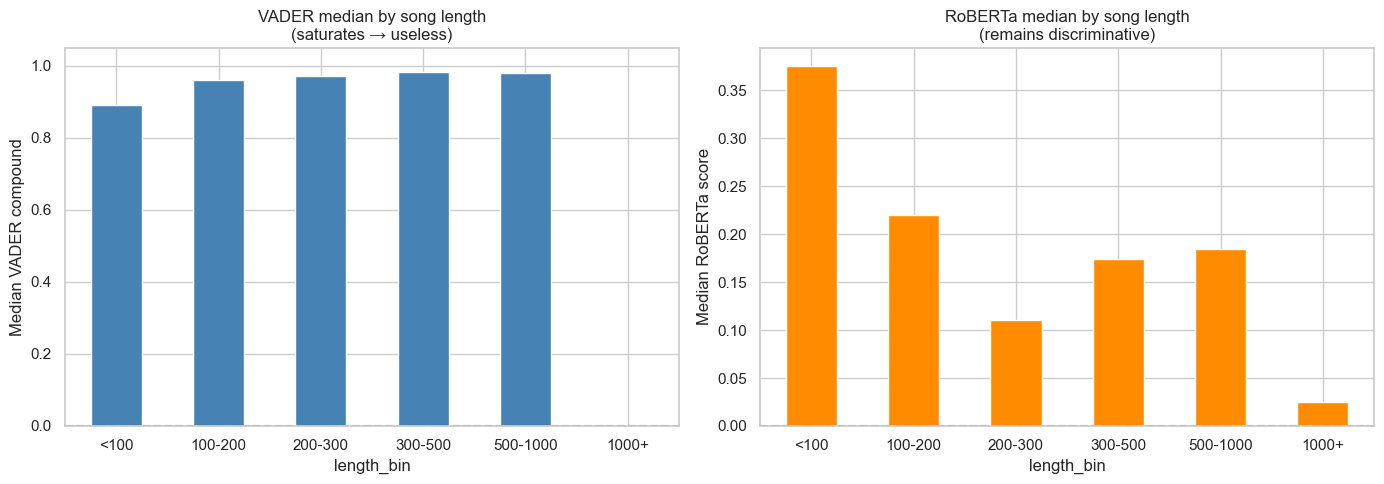

VADER stats by length bin:
             median       std  count
length_bin                          
<100        0.89100  0.613961     97
100-200     0.96000  0.725859   1094
200-300     0.97275  0.737727   1812
300-500     0.98380  0.786188   2219
500-1000    0.98040  0.874977   1275
1000+      -0.82830  0.983874     41

RoBERTa stats by length bin:
              median       std  count
length_bin                           
<100        0.375625  0.504006     97
100-200     0.220540  0.490429   1094
200-300     0.110865  0.462647   1812
300-500     0.173773  0.417428   2219
500-1000    0.184993  0.329580   1275
1000+       0.024545  0.323972     41


In [13]:
# The saturation problem visualized: VADER score by song length
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bin by length
df_en["length_bin"] = pd.cut(df_en["n_tokens"], 
    bins=[0, 100, 200, 300, 500, 1000, 5000],
    labels=["<100", "100-200", "200-300", "300-500", "500-1000", "1000+"])

# VADER median by length
vader_by_len = df_en.groupby("length_bin", observed=True)["vader"].agg(["median", "std", "count"])
roberta_by_len = df_en.groupby("length_bin", observed=True)["roberta"].agg(["median", "std", "count"])

vader_by_len["median"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("VADER median by song length\n(saturates → useless)")
axes[0].set_ylabel("Median VADER compound")
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0, color="gray", linestyle="--")
for tick in axes[0].get_xticklabels():
    tick.set_rotation(0)

roberta_by_len["median"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("RoBERTa median by song length\n(remains discriminative)")
axes[1].set_ylabel("Median RoBERTa score")
axes[1].axhline(0, color="gray", linestyle="--")
for tick in axes[1].get_xticklabels():
    tick.set_rotation(0)

plt.tight_layout(); plt.show()

print("VADER stats by length bin:")
print(vader_by_len)
print("\nRoBERTa stats by length bin:")
print(roberta_by_len)